# Open Data Tutorial — ATLAS Flavour-Tagging HDF5

This notebook walks through the basics of working with the SALT open-data HDF5 file used for jet flavour tagging studies.  
We cover:

1. **HDF5 basics** — opening files, navigating groups, inspecting datasets  
2. **Dataset structure** — jets, tracks, truth hadrons, and event-level info  
3. **Jet-level plots** — pT, η, flavour composition, tagger outputs  
4. **Track-level plots** — multiplicity, impact parameters, signed IP significance  
5. **Truth hadron info** — B-hadron Lxy, pT, decay vertex  
6. **Tagger performance** — ROC curves for GN2 and DL1d

## 0. Imports

In [3]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.metrics import roc_curve, auc

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

H5_FILE = 'mc-flavtag-ttbar-small.h5'

---
## 1. HDF5 Basics

HDF5 (Hierarchical Data Format 5) organises data into **groups** (like directories) and **datasets** (like NumPy arrays stored on disk). The Python library `h5py` provides dict-like access.

In [6]:
# Open in read-only mode — always use a context manager
with h5py.File(H5_FILE, 'r') as f:
    print('Top-level keys:', list(f.keys()))
    print()

    for name in f.keys():
        ds = f[name]
        print(f'  {name!r:20s}  shape={ds.shape}  dtype={ds.dtype.str[:8]}...')

Top-level keys: ['eventwise', 'jets', 'tracks', 'truth_hadrons']

  'eventwise'           shape=(1365435,)  dtype=|V26...
  'jets'                shape=(5619475,)  dtype=|V102...
  'tracks'              shape=(5619475, 40)  dtype=|V76...
  'truth_hadrons'       shape=(5619475, 5)  dtype=|V31...


In [8]:
# Structured (compound) dtype — each row is a record with named fields
with h5py.File(H5_FILE, 'r') as f:
    jet_fields   = f['jets'].dtype.names
    track_fields = f['tracks'].dtype.names

print('Jet fields   (', len(jet_fields), '):', jet_fields)
print()
print('Track fields (', len(track_fields), '):', track_fields)

Jet fields   ( 30 ): ('pt_btagJes', 'GN2v01_pb', 'GN2v01_pc', 'GN2v01_pu', 'GN2v01_ptau', 'DL1dv01_pu', 'DL1dv01_pc', 'DL1dv01_pb', 'eta_btagJes', 'pt', 'mass', 'ptFromTruthJet', 'etaFromTruthJet', 'phiFromTruthJet', 'mFromTruthJet', 'deltaEtaToTruthJet', 'deltaPhiToTruthJet', 'PartonTruthLabelPt', 'eta', 'phi', 'PartonTruthLabelDR', 'isJvtPU', 'isJvtHS', 'matchedToTruthJet', 'HadronConeExclTruthLabelID', 'HadronConeExclExtendedTruthLabelID', 'HadronGhostTruthLabelID', 'HadronGhostExtendedTruthLabelID', 'PartonTruthLabelID', 'eventNumber')

Track fields ( 36 ): ('numberOfInnermostPixelLayerHits', 'numberOfNextToInnermostPixelLayerHits', 'numberOfInnermostPixelLayerSharedHits', 'numberOfInnermostPixelLayerSplitHits', 'numberOfPixelHits', 'numberOfPixelSharedHits', 'numberOfPixelSplitHits', 'numberOfSCTHits', 'numberOfSCTSharedHits', 'GN2v01_trackOrigin', 'GN2v01_vertexIndex', 'ftagTruthParentBarcode', 'ftagTruthOriginLabel', 'ftagTruthVertexIndex', 'theta', 'qOverP', 'pt', 'ptfrac', 'de

In [10]:
# Slicing — h5py supports NumPy-style fancy indexing
# Only load what you need; avoid loading the whole file at once
with h5py.File(H5_FILE, 'r') as f:
    # Read first 5 jets as a structured array
    sample_jets = f['jets'][:5]

print('pt [GeV]:', sample_jets['pt'] / 1e3)
print('eta     :', sample_jets['eta'])
print('HadronConeExclTruthLabelID:', sample_jets['HadronConeExclTruthLabelID'])

pt [GeV]: [123.472824 109.78911   73.05592   99.27973   60.097782]
eta     : [-0.5625 -0.6587 -0.1439  1.258   2.312 ]
HadronConeExclTruthLabelID: [0 5 5 5 4]


---
## 2. Load a Working Sample

The file has ~5.6 M jets. We load a manageable slice for exploration.

In [13]:
N = 200_000   # jets to load

with h5py.File(H5_FILE, 'r') as f:
    jets    = f['jets'][:N]
    tracks  = f['tracks'][:N]          # shape (N, 40) — up to 40 tracks per jet
    hadrons = f['truth_hadrons'][:N]   # shape (N,  5) — up to 5 truth hadrons

flavour = jets['HadronConeExclTruthLabelID']

# Standard labelling: 5=b, 4=c, 0=light
is_b = flavour == 5
is_c = flavour == 4
is_l = flavour == 0

print(f'b-jets : {is_b.sum():>7,}  ({is_b.mean():.1%})')
print(f'c-jets : {is_c.sum():>7,}  ({is_c.mean():.1%})')
print(f'light  : {is_l.sum():>7,}  ({is_l.mean():.1%})')
print(f'other  : {(~(is_b|is_c|is_l)).sum():>7,}')

b-jets :  75,194  (37.6%)
c-jets :  17,598  (8.8%)
light  :  99,800  (49.9%)
other  :   7,408


---
## 3. Jet-Level Distributions

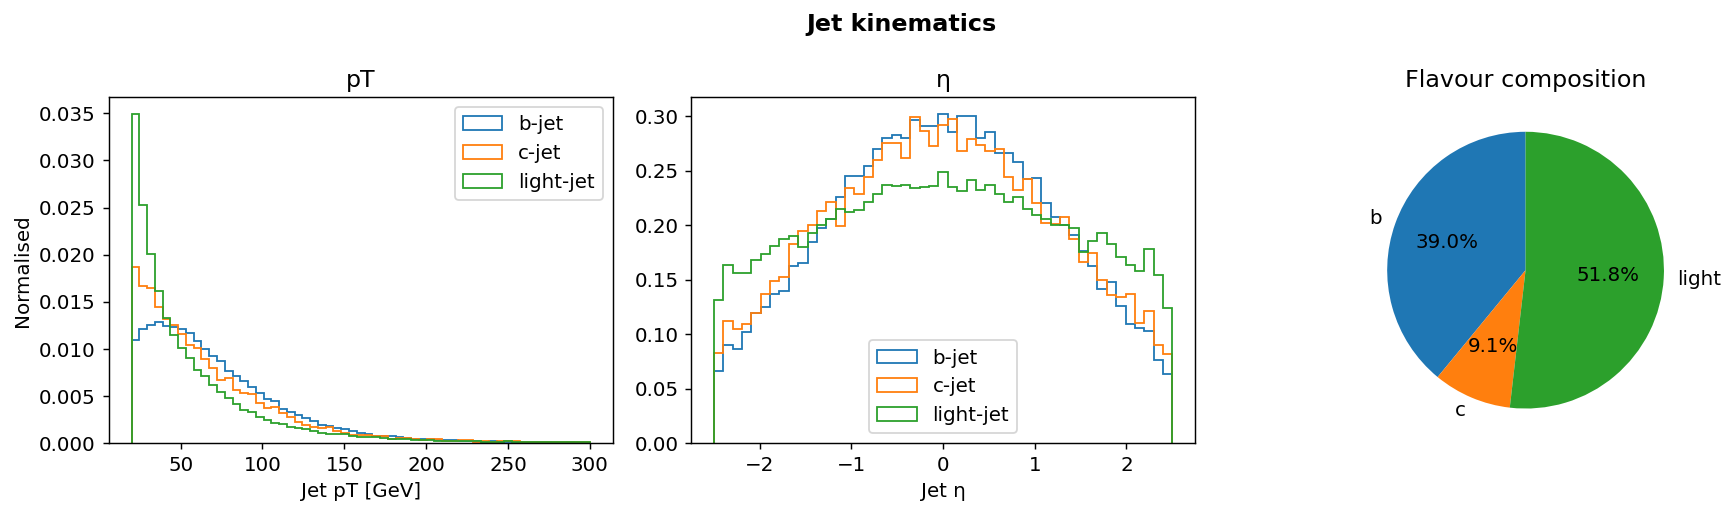

In [16]:
pt  = jets['pt'] / 1e3   # GeV
eta = jets['eta']

COLOURS = {'b': '#1f77b4', 'c': '#ff7f0e', 'light': '#2ca02c'}
masks   = {'b': is_b, 'c': is_c, 'light': is_l}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Jet kinematics', fontweight='bold')

# pT
bins_pt = np.linspace(20, 300, 60)
for lbl, mask in masks.items():
    axes[0].hist(pt[mask], bins=bins_pt, histtype='step', density=True,
                 color=COLOURS[lbl], label=f'{lbl}-jet')
axes[0].set_xlabel('Jet pT [GeV]');  axes[0].set_ylabel('Normalised')
axes[0].set_title('pT'); axes[0].legend()

# η
bins_eta = np.linspace(-2.5, 2.5, 50)
for lbl, mask in masks.items():
    axes[1].hist(eta[mask], bins=bins_eta, histtype='step', density=True,
                 color=COLOURS[lbl], label=f'{lbl}-jet')
axes[1].set_xlabel('Jet η'); axes[1].set_title('η'); axes[1].legend()

# Flavour pie
counts = [is_b.sum(), is_c.sum(), is_l.sum()]
axes[2].pie(counts, labels=['b', 'c', 'light'],
            colors=[COLOURS['b'], COLOURS['c'], COLOURS['light']],
            autopct='%1.1f%%', startangle=90)
axes[2].set_title('Flavour composition')

plt.tight_layout()
plt.show()

---
## 4. Tagger Score Distributions

The file contains output probabilities from two ATLAS taggers:

- **GN2v01** — graph-neural-network based (state of the art)  
- **DL1dv01** — deep-learning tagger (predecessor)

Both output $(p_b, p_c, p_u)$.  The standard b-tagging discriminant is
$$D_b = \log\frac{p_b}{f_c\,p_c + (1-f_c)\,p_u}, \quad f_c = 0.2$$

/var/folders/1f/fh3hss417dlc_9pw9wv1h3nc0000gq/T/ipykernel_17207/2881644552.py:2: RuntimeWarning: overflow encountered in divide
  return np.log(pb / (fc * pc + (1 - fc) * pu + 1e-10))


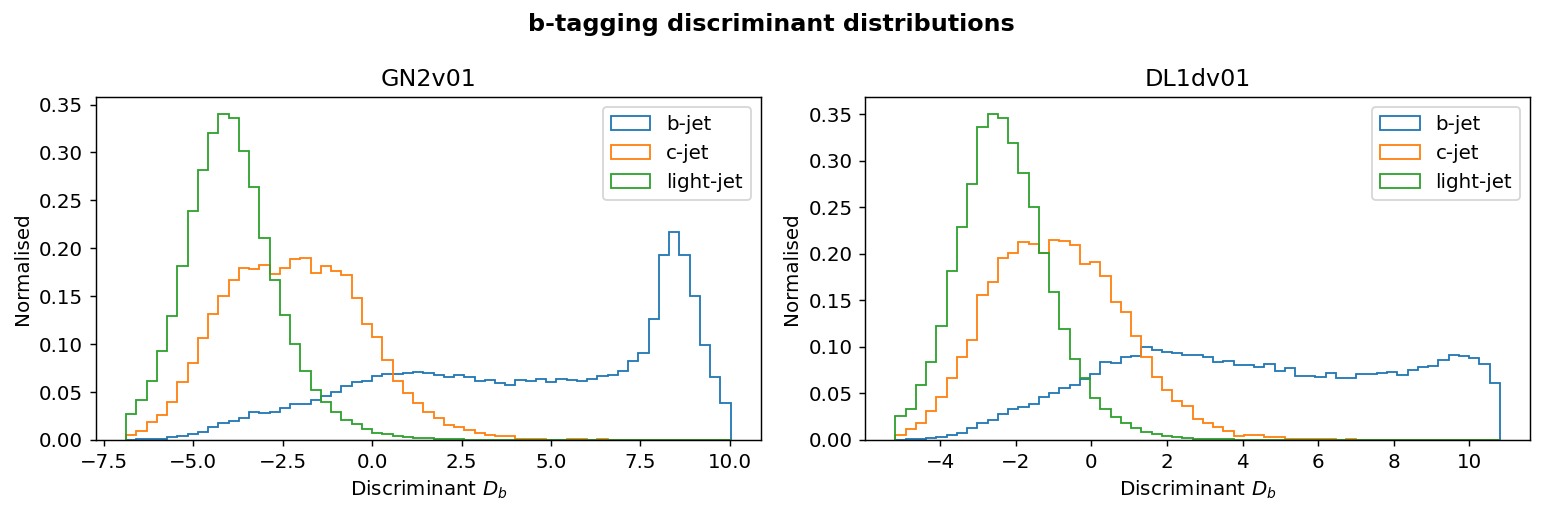

In [19]:
def disc(pb, pc, pu, fc=0.2):
    return np.log(pb / (fc * pc + (1 - fc) * pu + 1e-10))

gn2_disc  = disc(jets['GN2v01_pb'],  jets['GN2v01_pc'],  jets['GN2v01_pu'])
dl1d_disc = disc(jets['DL1dv01_pb'], jets['DL1dv01_pc'], jets['DL1dv01_pu'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('b-tagging discriminant distributions', fontweight='bold')

for ax, d, title in zip(axes,
                        [gn2_disc, dl1d_disc],
                        ['GN2v01', 'DL1dv01']):
    finite = np.isfinite(d)
    lo, hi = np.percentile(d[finite], [0.5, 99.5])
    bins = np.linspace(lo, hi, 60)
    for lbl, mask in masks.items():
        m = mask & finite
        ax.hist(d[m], bins=bins, histtype='step', density=True,
                color=COLOURS[lbl], label=f'{lbl}-jet')
    ax.set_xlabel('Discriminant $D_b$')
    ax.set_ylabel('Normalised')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

---
## 5. ROC Curves — Tagger Performance Comparison

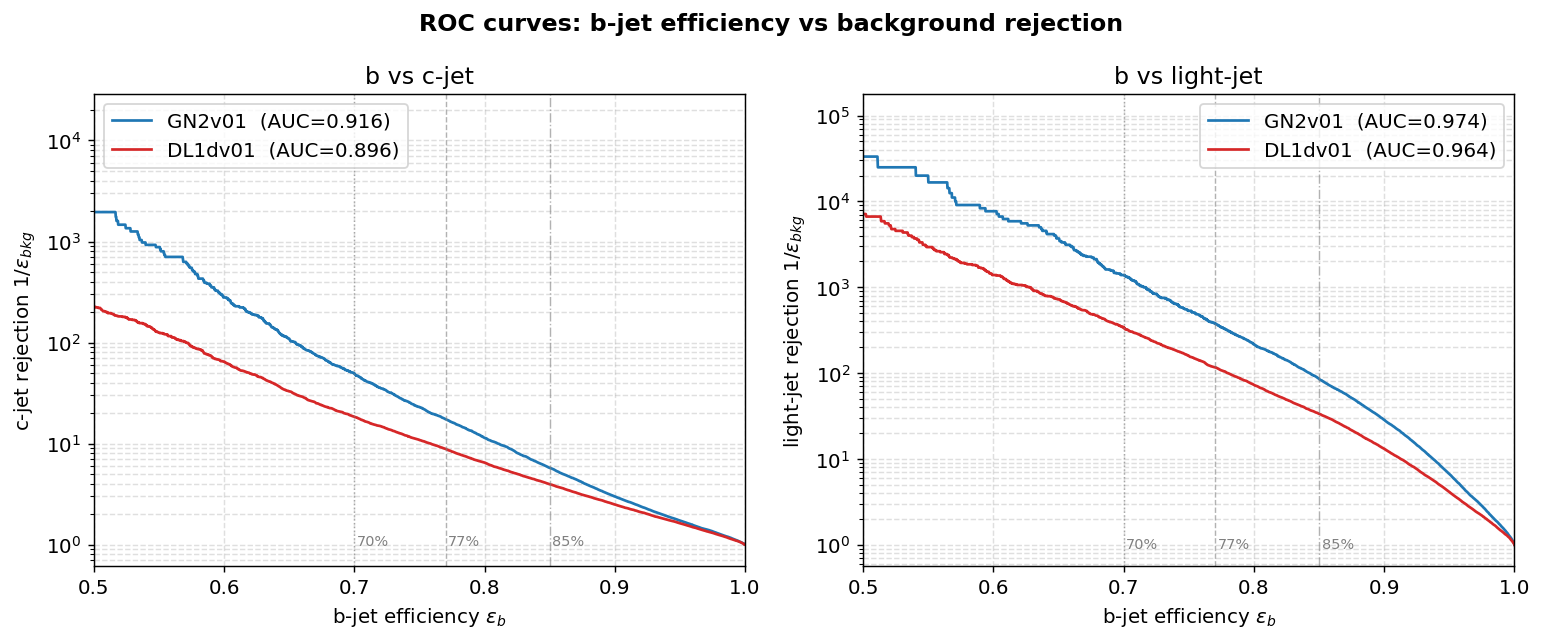

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('ROC curves: b-jet efficiency vs background rejection', fontweight='bold')

taggers = [
    ('GN2v01',  gn2_disc,  '#1f77b4'),
    ('DL1dv01', dl1d_disc, '#d62728'),
]

for ax, (bkg_mask, bkg_label) in zip(axes, [(is_c, 'c-jet'), (is_l, 'light-jet')]):
    for tag_name, d, col in taggers:
        sel = (is_b | bkg_mask) & np.isfinite(d)
        y   = is_b[sel].astype(int)
        fpr, tpr, _ = roc_curve(y, d[sel])
        rejection   = 1.0 / np.where(fpr > 0, fpr, np.nan)
        ax.plot(tpr, rejection, color=col, lw=1.5,
                label=f'{tag_name}  (AUC={auc(fpr, tpr):.3f})')
    ax.set_xlabel('b-jet efficiency $\\varepsilon_b$')
    ax.set_ylabel(f'{bkg_label} rejection $1/\\varepsilon_{{bkg}}$')
    ax.set_title(f'b vs {bkg_label}')
    ax.set_yscale('log')
    ax.set_xlim(0.5, 1.0)
    ax.legend()
    ax.grid(True, which='both', ls='--', alpha=0.4)
    # Mark common working points
    for wp, ls in [(0.70, ':'), (0.77, '--'), (0.85, '-.')]: 
        ax.axvline(wp, color='grey', lw=0.8, ls=ls, alpha=0.6)
        ax.text(wp + 0.002, ax.get_ylim()[0]*1.5, f'{int(wp*100)}%',
                fontsize=8, color='grey', va='bottom')

plt.tight_layout()
plt.show()

---
## 6. Track-Level Distributions

The `tracks` dataset has shape `(N_jets, 40)` — up to 40 tracks per jet stored as a padded array.  
The `valid` boolean field marks which slots are real tracks.

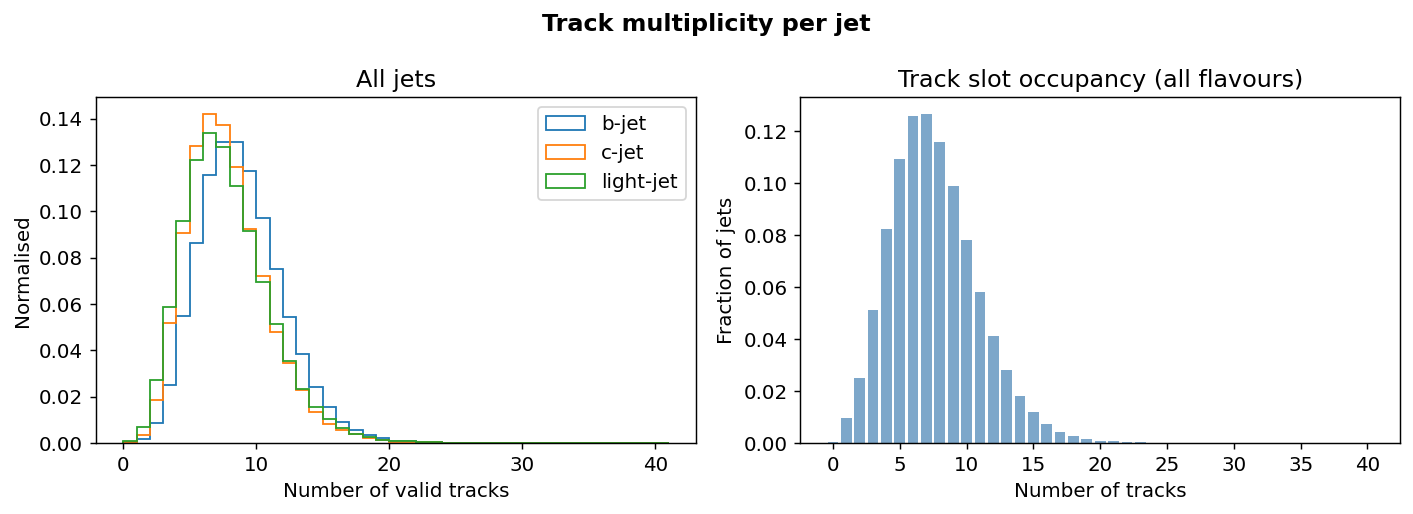

In [25]:
valid      = tracks['valid']                          # (N, 40) bool
n_tracks   = valid.sum(axis=1)                        # (N,) int — tracks per jet

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Track multiplicity per jet', fontweight='bold')

bins = np.arange(0, 42)
for lbl, mask in masks.items():
    axes[0].hist(n_tracks[mask], bins=bins, histtype='step', density=True,
                 color=COLOURS[lbl], label=f'{lbl}-jet')
axes[0].set_xlabel('Number of valid tracks'); axes[0].set_ylabel('Normalised')
axes[0].set_title('All jets'); axes[0].legend()

# Fraction of jets with exactly N tracks filled
axes[1].bar(np.arange(41), [(n_tracks == k).mean() for k in range(41)],
            color='steelblue', alpha=0.7)
axes[1].set_xlabel('Number of tracks'); axes[1].set_ylabel('Fraction of jets')
axes[1].set_title('Track slot occupancy (all flavours)')

plt.tight_layout()
plt.show()

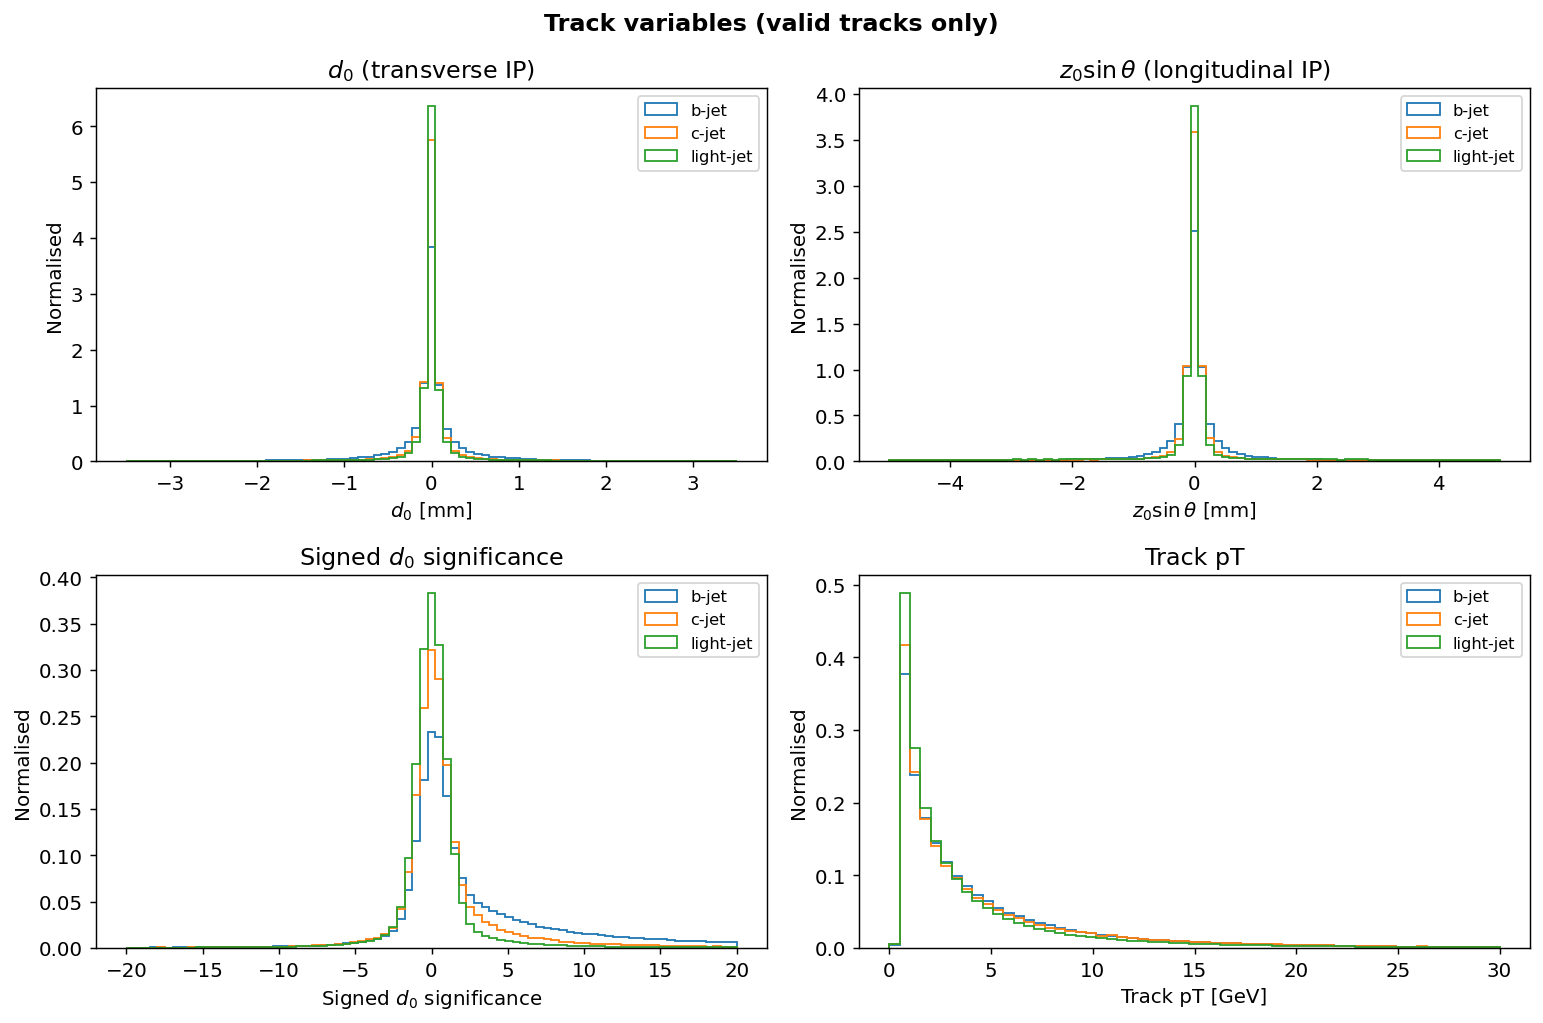

In [27]:
# Flatten valid tracks into a 1-D array for each variable
flat_idx  = np.repeat(np.arange(N), 40)   # jet index for each slot
flat_flav = flavour[flat_idx]
flat_valid = valid.ravel()

d0  = tracks['d0'].ravel()
z0  = tracks['z0SinTheta'].ravel()
ip2d= tracks['lifetimeSignedD0Significance'].ravel()
pt_t= tracks['pt'].ravel() / 1e3   # GeV

def sel(mask_jet, var):
    """Return track-level variable for jets passing mask_jet, valid tracks only."""
    m = flat_valid & np.isin(flat_flav, np.where(mask_jet)[0] if False else [])
    # simpler:
    jet_pass = np.zeros(N, bool)
    jet_pass[mask_jet] = True
    m2 = flat_valid & jet_pass[flat_idx]
    return var[m2]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Track variables (valid tracks only)', fontweight='bold')

panel_cfg = [
    (axes[0,0], d0,   np.linspace(-3.5, 3.5, 80), '$d_0$ [mm]',    '$d_0$ (transverse IP)'),
    (axes[0,1], z0,   np.linspace(-5,   5,   80), '$z_0\\sin\\theta$ [mm]', '$z_0\\sin\\theta$ (longitudinal IP)'),
    (axes[1,0], ip2d, np.linspace(-20,  20,  80), 'Signed $d_0$ significance', 'Signed $d_0$ significance'),
    (axes[1,1], pt_t, np.linspace(0,    30,  60), 'Track pT [GeV]',  'Track pT'),
]

for ax, var, bins, xlabel, title in panel_cfg:
    for lbl, mask in masks.items():
        v = sel(mask, var)
        v = v[np.isfinite(v)]
        ax.hist(v, bins=bins, histtype='step', density=True,
                color=COLOURS[lbl], label=f'{lbl}-jet')
    ax.set_xlabel(xlabel); ax.set_ylabel('Normalised')
    ax.set_title(title); ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 7. Truth Hadron Information

The `truth_hadrons` dataset provides MC-truth B (and C) hadrons ghost-associated to each jet.  
Key quantity: **Lxy** — transverse flight distance of the B-hadron decay, the physical origin of the displaced-track signal.

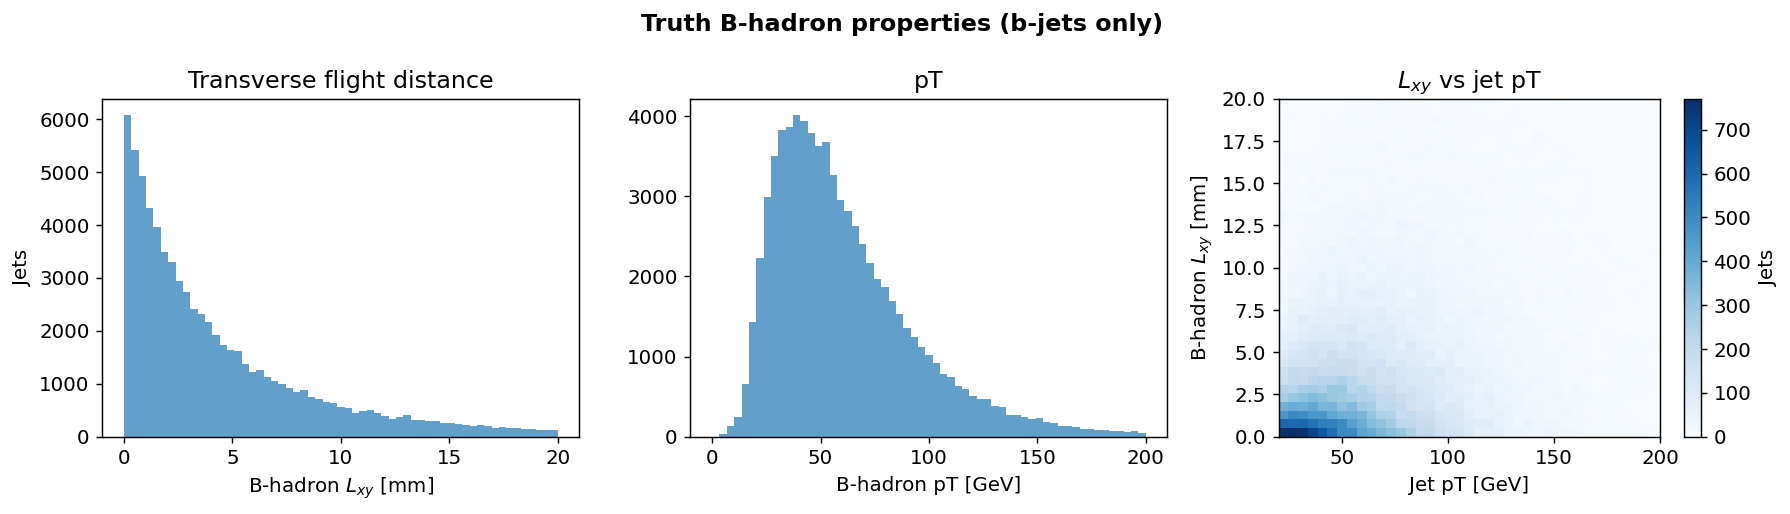

In [33]:
had_valid = hadrons['valid']    # (N, 5) bool
had_Lxy   = hadrons['Lxy']     # mm
had_pt    = hadrons['pt'] / 1e3
had_deta  = hadrons['deta']
had_dphi  = hadrons['dphi']

# For b-jets take the leading (first) valid hadron
b_mask_jet = is_b
lead_Lxy   = np.full(N, np.nan)
lead_pt_h  = np.full(N, np.nan)
for i in range(5):
    slot_valid = had_valid[:, i]
    update     = b_mask_jet & slot_valid & np.isnan(lead_Lxy)
    lead_Lxy[update]  = had_Lxy[update, i]
    lead_pt_h[update] = had_pt[update, i]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Truth B-hadron properties (b-jets only)', fontweight='bold')

v = lead_Lxy[np.isfinite(lead_Lxy)]
axes[0].hist(v, bins=np.linspace(0, 20, 60), color='#1f77b4', alpha=0.7)
axes[0].set_xlabel('B-hadron $L_{xy}$ [mm]'); axes[0].set_ylabel('Jets')
axes[0].set_title('Transverse flight distance')

v2 = lead_pt_h[np.isfinite(lead_pt_h)]
axes[1].hist(v2, bins=np.linspace(0, 200, 60), color='#1f77b4', alpha=0.7)
axes[1].set_xlabel('B-hadron pT [GeV]'); axes[1].set_title('pT')

# 2D: Lxy vs jet pT
both = np.isfinite(lead_Lxy) & np.isfinite(pt)
h2, xe, ye = np.histogram2d(pt[both], lead_Lxy[both],
                             bins=[np.linspace(20,200,40), np.linspace(0,20,40)])
im = axes[2].pcolormesh(xe, ye, h2.T, cmap='Blues')
plt.colorbar(im, ax=axes[2], label='Jets')
axes[2].set_xlabel('Jet pT [GeV]'); axes[2].set_ylabel('B-hadron $L_{xy}$ [mm]')
axes[2].set_title('$L_{xy}$ vs jet pT')

plt.tight_layout()
plt.show()

---
## 9. Track Origin Labels

The `ftagTruthOriginLabel` field encodes where each track comes from according to MC truth.  
**Always use this field for physics analysis** — `GN2v01_trackOrigin` is the tagger's *prediction*, not truth.

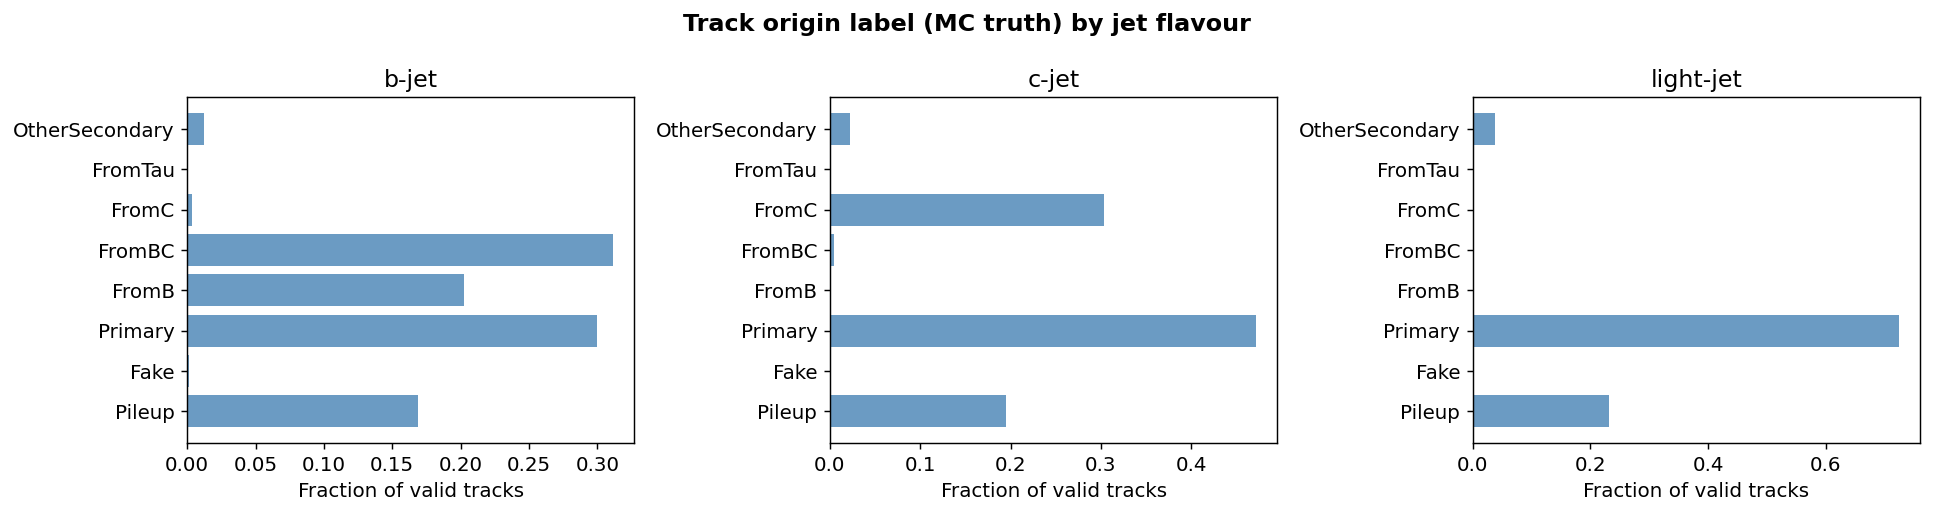

In [36]:
ORIGIN_LABELS = {
    0:  'Pileup',
    1:  'Fake',
    2:  'Primary',
    3:  'FromB',
    4:  'FromBC',
    5:  'FromC',
    6:  'FromTau',
    7:  'OtherSecondary',
}

origin = tracks['ftagTruthOriginLabel'].ravel()   # all slots

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Track origin label (MC truth) by jet flavour', fontweight='bold')

for ax, (lbl, mask) in zip(axes, masks.items()):
    jet_pass = np.zeros(N, bool)
    jet_pass[mask] = True
    sel_tracks = flat_valid & jet_pass[flat_idx]
    o = origin[sel_tracks]
    codes, counts = np.unique(o, return_counts=True)
    names = [ORIGIN_LABELS.get(int(c), str(c)) for c in codes]
    ax.barh(names, counts / counts.sum(), color='steelblue', alpha=0.8)
    ax.set_xlabel('Fraction of valid tracks')
    ax.set_title(f'{lbl}-jet')

plt.tight_layout()
plt.show()

---
## 10. Summary

| Group | Shape | Content |
|---|---|---|
| `jets` | (5.6M,) | Jet kinematics, truth labels, tagger outputs |
| `tracks` | (5.6M, 40) | Up to 40 tracks per jet; padded with `valid=False` |
| `truth_hadrons` | (5.6M, 5) | MC truth B/C hadrons ghost-matched to the jet |
| `eventwise` | (1.4M,) | Event-level: nJets, primary vertex position |

**Key take-aways:**
- b-jets produce tracks with large positive signed $d_0$ significance — the classic lifetime signature
- B-hadrons have $L_{xy} \sim 3$–10 mm, growing with pT
- GN2v01 significantly outperforms DL1dv01 across both ROC curves
- Even the simple mean-IP baseline provides meaningful b vs light separation